In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.autograd as autograd
device = 'cuda:0'
import torch
import numpy as np

class Problems():
    def dlX_disp(self):
        domain_xcoord = np.random.uniform(-self.nelx/(2*(self.nelm)),self.nelx/(2*(self.nelm)),(self.batch_size-300,1))
        domain_ycoord = np.random.uniform(-self.nely/(2*(self.nelm)),self.nely/(2*(self.nelm)),(self.batch_size-300,1))
        domain_coord = np.concatenate((domain_ycoord,domain_xcoord),axis = 1)
        coord = np.concatenate((self.sample_fixed_points().cpu().detach().numpy(), self.sample_force_points().cpu().detach().numpy()),axis = 0)
        coord = np.concatenate((coord, domain_coord),axis = 0)
        coord = torch.tensor(coord,dtype=torch.float32,requires_grad=True).to(device)
        return coord

class MBB_Beam_2D(Problems):
    def __init__(self, nelx, nely, vf):
        # -------------------------
        # Initialize geometry parameters
        # -------------------------
        self.nelx = nelx
        self.nely = nely
        self.nele = self.nelx * self.nely
        self.nelm = max(self.nelx, self.nely) // 2
        self.volfrac = vf
        self.E0 = 1
        self.nu = 0.3
        
        self.batch_size = 25000
        self.alpha_init = 1
        self.alpha_max = 100
        self.alpha_delta = 0.5
        self.penal = 3.0

        # -------------------------
        # Generate mesh coordinates
        # -------------------------
        c_y, c_x = np.meshgrid(
            np.linspace(-self.nely/(2*self.nelm), self.nely/(2*self.nelm), self.nely),
            np.linspace(-self.nelx/(2*self.nelm), self.nelx/(2*self.nelm), self.nelx),
            indexing='ij'
        )
        self.dlX = np.stack((c_y.reshape([-1]), c_x.reshape([-1])), axis=1).reshape([-1,2])

        c_y_fine, c_x_fine = np.meshgrid(
            np.linspace(-self.nely/(2*self.nelm), self.nely/(2*self.nelm), 2*self.nely),
            np.linspace(-self.nelx/(2*self.nelm), self.nelx/(2*self.nelm), 2*self.nelx),
            indexing='ij'
        )
        self.dlXSS = np.stack((c_y_fine.reshape([-1]), c_x_fine.reshape([-1])), axis=1).reshape([-1,2])
        self.V = (np.max(self.dlX[:,0])-np.min(self.dlX[:,0]))*(np.max(self.dlX[:,1])-np.min(self.dlX[:,1]))

        # -------------------------
        # Boundary conditions for MBB beam
        # -------------------------
        tol = 1e-5
        '''
        # Fixed supports at two bottom corners
        fixed_voxel = np.zeros((self.nely, self.nelx))
        # Bottom-left support: x in [-1, -0.95], y = -0.5
        fixed_voxel[((c_y >= 0.5 - tol) & (c_y <= 0.5 + tol) & (c_x >= -1.0) & (c_x <= -0.95))] = 1
        # Bottom-right support: x in [0.95, 1.0], y = -0.5
        fixed_voxel[((c_y >= 0.5 - tol) & (c_y <= 0.5 + tol) & (c_x >= 0.95) & (c_x <= 1.0))] = 1

        dlX_fixed = self.dlX[np.where(fixed_voxel.reshape(-1) == 1)[0], :]

        # Force applied at center of bottom edge: x in [-0.05,0.05], y = -0.5
        force_voxel = np.zeros((self.nely, self.nelx))
        force_voxel[(c_y >= 0.5 - tol) & (c_y <= 0.5 + tol) & (c_x >= -0.05) & (c_x <= 0.05)] = 1
        dlX_force = self.dlX[np.where(force_voxel.reshape(-1) == 1)[0], :]
        '''
        # Force vector (downward)
        self.F_vector = torch.tensor([[1],[0.0]], dtype=torch.float32).to(device)

        # -------------------------
        # Convert to torch tensors
        # -------------------------
        self.dlX = torch.tensor(self.dlX, dtype=torch.float32, requires_grad=True).to(device)
        self.dlXSS = torch.tensor(self.dlXSS, dtype=torch.float32, requires_grad=True).to(device)
        '''
        self.dlX_fixed = torch.tensor(dlX_fixed, dtype=torch.float32, requires_grad=True).to(device)
        self.dlX_force = torch.tensor(dlX_force, dtype=torch.float32, requires_grad=True).to(device)
        '''
    def sample_fixed_points(self,n_samples_per_corner=100):
        """
        在固定边界区域生成多采样点
        返回 tensor: (n_samples_total, 2)
        """
        tol_y = 1e-5
        # 左下角 x ∈ [-1, -0.95], y = -0.5
        x_left = np.random.uniform(-1.0, -0.95, n_samples_per_corner)
        y_left = np.full_like(x_left, 0.5)
        left_points = np.stack([y_left, x_left], axis=1)

        # 右下角 x ∈ [0.95, 1.0], y = -0.5
        x_right = np.random.uniform(0.95, 1.0, n_samples_per_corner)
        y_right = np.full_like(x_right, 0.5)
        right_points = np.stack([y_right, x_right], axis=1)   

        fixed_samples = np.vstack([left_points, right_points])
        return torch.tensor(fixed_samples, dtype=torch.float32, requires_grad=True).to(device)
    
    def sample_force_points(self,n_samples_per_corner=2):
        """
        在固定边界区域生成多采样点
        返回 tensor: (n_samples_total, 2)
        """
        tol_y = 1e-5
        # 左下角 x ∈ [-1, -0.95], y = -0.5
        x_left = np.random.uniform(-0.00, 0.00, n_samples_per_corner)
        y_left = np.full_like(x_left, 0.5)
        left_points = np.stack([y_left, x_left], axis=1)
        return torch.tensor(left_points, dtype=torch.float32, requires_grad=True).to(device)
    
    def analytical_fixed_BC(self,u,coord):
        u = u*2*(1/(1+torch.exp(-20*(coord[:,0:1]-0.5))) - 0.5)
        return u
    
class PINN():
    def __init__(self, problem, disp_model):
        self.problem = problem
        self.disp_model = disp_model
    
    def sample_fixed_points(self,n_samples_per_corner=2):
        """
        在固定边界区域生成多采样点
        返回 tensor: (n_samples_total, 2)
        """
        tol_y = 1e-5
        # 左下角 x ∈ [-1, -0.95], y = -0.5
        x_left = np.random.uniform(-1.0, -1.0, n_samples_per_corner)
        y_left = np.full_like(x_left, 0.5)
        left_points = np.stack([y_left, x_left], axis=1)

        # 右下角 x ∈ [0.95, 1.0], y = -0.5
        x_right = np.random.uniform(1.0, 1.0, n_samples_per_corner)
        y_right = np.full_like(x_right, 0.5)
        right_points = np.stack([y_right, x_right], axis=1)

        fixed_samples = np.vstack([left_points, right_points])
        return torch.tensor(fixed_samples, dtype=torch.float32, requires_grad=True).to(device)
    
    def sample_force_points(self,n_samples_per_corner=2):
        """
        在固定边界区域生成多采样点
        返回 tensor: (n_samples_total, 2)
        """
        tol_y = 1e-5
        # 左下角 x ∈ [-1, -0.95], y = -0.5
        x_left = np.random.uniform(-0.00, 0.00, n_samples_per_corner)
        y_left = np.full_like(x_left, 0.5)
        left_points = np.stack([y_left, x_left], axis=1)
        return torch.tensor(left_points, dtype=torch.float32, requires_grad=True).to(device)
    

    def pinn_loss(self,xPhys_m, coord):
        u = self.disp_model(coord)
        #u = self.problem.analytical_fixed_BC(u,coord)
        u1 = u[:,0:1]
        u0 = u[:,1:2]
        uy_xyz = torch.autograd.grad(outputs=u1, inputs=coord,
                                        grad_outputs=torch.ones_like(u1),
                                        create_graph = True, retain_graph = True)[0]
        ux_xyz = torch.autograd.grad(outputs=u0, inputs=coord,
                                        grad_outputs=torch.ones_like(u0),
                                        create_graph = True, retain_graph = True)[0]
                                        
        eps11 = ux_xyz[:,1]
        eps12 = 0.5 * ux_xyz[:,0] + 0.5 * uy_xyz[:,1]
        eps22 = uy_xyz[:,0]

        youngs_modulus = 1
        poissons_ratio = 0.3
        lame_mu = youngs_modulus / (2.0 * (1.0 + poissons_ratio))
        lame_lambda = youngs_modulus * poissons_ratio / (1.0+ poissons_ratio)/( 1.0- 2*poissons_ratio)
        trace_strain = eps11 + eps22
        squared_diagonal = eps11 * eps11 + eps22 * eps22
        energy = 0.5 * lame_lambda * trace_strain * trace_strain + lame_mu * (squared_diagonal + 2.0 * eps12 * eps12)
        energy = energy.reshape(-1,1)*(xPhys_m**3.0)
        energy_c = energy
        energy_ans = self.problem.V*torch.mean(energy)
        force_l = torch.mean(torch.matmul(self.disp_model(self.sample_force_points()),self.problem.F_vector))#*0.1

        
        fixed_samples = self.sample_fixed_points()
        u_fixed = self.disp_model(fixed_samples)[:,0:1]
        bc_loss = torch.mean(u_fixed**2) # L2 loss on fixed points
        # ------------------------
        # Total PINN loss
        # ------------------------
        
        loss = (energy_ans - force_l) + 100 * bc_loss  # 可以加权： e.g., loss = energy_ans - force_l + alpha*bc_loss
        return loss, energy_c
    
import torch.nn.functional as F
import torch
import torch.nn as nn
import numpy as np


class TO_Net(nn.Module):
    def __init__(self):
        super(TO_Net, self).__init__()
        low_band = 0.0
        high_band = 35
        c_y, c_x=np.meshgrid(np.linspace([-high_band,low_band],[-low_band,high_band],20).reshape([-1]),
                                                    np.linspace([-high_band,low_band],[-low_band,high_band],20).reshape([-1])
                                                    ,indexing='ij')
        self.kernel1 = torch.tensor(np.stack((c_y.reshape([-1]),c_x.reshape([-1])),axis = 0),dtype=torch.float32).to(device)
        self.kernel1 = torch.nn.Parameter(self.kernel1.requires_grad_())
        self.weights1 = torch.zeros([self.kernel1.shape[1],1],dtype=torch.float32).to(device)
        self.weights1 = torch.nn.Parameter(self.weights1.requires_grad_())
            
    def forward(self, x):
        y = torch.sin(torch.matmul(x,1.0* self.kernel1 ) + torch.ones([1,self.kernel1.shape[1]]).to(device))
        y = torch.sigmoid(torch.matmul(y, self.weights1))
        return y
    
class Disp_Net(nn.Module):
    def __init__(self):
        super(Disp_Net, self).__init__()
        low_band = 0.0
        high_band = 35
        c_y, c_x=np.meshgrid(np.linspace([-high_band,low_band],[-low_band,high_band],30).reshape([-1]),
                                                    np.linspace([-high_band,low_band],[-low_band,high_band],30).reshape([-1]),
                                                    indexing='ij')
        self.kernel1 = torch.tensor(np.stack((c_y.reshape([-1]),c_x.reshape([-1])),axis = 0),dtype=torch.float32).to(device)
        self.kernel1 = torch.nn.Parameter(self.kernel1.requires_grad_())
        self.weights1 = torch.zeros([self.kernel1.shape[1],2],dtype=torch.float32).to(device)
        self.weights1 = torch.nn.Parameter(self.weights1.requires_grad_())
    def forward(self, x):
        y = torch.sin(torch.matmul(x,1.0* self.kernel1 ) + torch.ones([1,self.kernel1.shape[1]]).to(device))
        y = torch.matmul(y, self.weights1)
        return y
    
import torch.optim as optim
from IPython import display
import numpy as np
import time

class DMF_TONN():

    def __init__(self, problem, to_model, disp_model):
        self.problem = problem
        self.disp_model = disp_model
        self.to_model = to_model
        self.log_vf = []
        self.log_disp_loss = []
        self.log_c = []
        self.log_pinn_init_loss = []
        self.log_fec = []
        self.log_xPhys = []
        self.pinn = PINN(self.problem, self.disp_model)
        self.total_epoch = 0

        self.disp_optimizer = optim.Adam(self.disp_model.parameters(), lr=0.000005)
        self.to_optimizer = optim.Adam(self.to_model.parameters(), lr=0.002)
        #self.coord = problem.dlX_disp()
  
    def fit_disp_init(self):
        epochs = 2000
        for epoch in range(epochs):
            if epoch % 100 == 1:
                display.clear_output(wait=True)

            coord = self.problem.dlX_disp()
            xPhys = torch.ones(coord.shape[0], 1) * 0.5
            loss, energy_c = self.pinn.pinn_loss(xPhys.to(device), coord)
            self.log_pinn_init_loss.append(loss.item())
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()

        xPhys = torch.ones(self.problem.dlX.shape[0], 1) * 0.5
        loss, energy_c = self.pinn.pinn_loss(xPhys.to(device), self.problem.dlX)
        self.c1 = energy_c
        self.c_0 = torch.mean(energy_c)
    
    def to_loss(self, coord):
        self.total_epoch = self.total_epoch + 1
        
        # 相场网络输出
        xPhys_m = self.to_model(coord)  # [N,1]，sigmoid保证0-1

        # 动态alpha更新
        alpha = min(self.problem.alpha_init + self.problem.alpha_delta * self.total_epoch, self.problem.alpha_max)

        # 计算柔度能量
        _, energy_c = self.pinn.pinn_loss(xPhys_m, coord)

        # 自定义反向传播
        class ComputeDeDrho(torch.autograd.Function):
            @staticmethod
            def forward(ctx, xPhys_m, energy_c, coord):
                ctx.save_for_backward(xPhys_m, energy_c, coord)
                return energy_c

            @staticmethod
            def backward(ctx, denergy):
                xPhys_m, energy_c, coord = ctx.saved_tensors
                grad_energy = torch.autograd.grad(
                    outputs=energy_c,
                    inputs=xPhys_m,
                    grad_outputs=denergy,
                    create_graph=True,
                    retain_graph=True
                )[0]
                # 返回负梯度
                return -grad_energy, torch.zeros_like(energy_c), torch.zeros_like(coord)

        # 计算柔度损失 c
        c = torch.mean(ComputeDeDrho.apply(xPhys_m, energy_c, coord))

        # 体积约束
        xPhys_dlX = self.to_model(self.problem.dlX)
        vf = torch.mean(xPhys_dlX)



        # -------------------
        # 总损失
        # -------------------
        loss = alpha * (vf / self.problem.volfrac - 1.0) ** 2 + 1 * c / self.c_0.detach()

        print('Epoch:', self.total_epoch)
        print('Total Loss:', loss.item())
        print("c:", c.item())
        
        # 日志记录
        self.log_c.append(c.item())
        self.log_vf.append(vf.item())
        self.log_xPhys.append(xPhys_dlX.detach())

        return loss
    

    def fit_disp(self, epochs=500):
        for i in range(epochs):
            coord = self.problem.dlX_disp()
            xPhys_m = self.to_model(coord)
            loss, _ = self.pinn.pinn_loss(xPhys_m, coord)
            self.log_disp_loss.append(loss.item())
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()
           
    
    def fit_to(self, epochs):
        self.time_pde=[]
        self.time_density=[]
        for epoch in range(epochs):
            t1= time.time()
            self.fit_disp(50)
            t2 = time.time()
            self.time_pde.append(t2-t1)
            if epoch % 10 == 1:
                display.clear_output(wait=True)

            coord = self.problem.dlX_disp()
            t1= time.time()
            loss = self.to_loss(coord)
            self.to_optimizer.zero_grad()
            loss.backward()
            self.to_optimizer.step()
            t2 = time.time()
            self.time_density.append(t2-t1)

nelx = 80
nely = 40

#User defined load location
xid = 29
yid = 0

#User defined target volume fraction
vf = 0.5
problem= MBB_Beam_2D(nelx,nely,vf)#Cantilever_Beam_2D(nelx,nely,xid,yid,vf)
to_model= TO_Net().to(device)
disp_model_h = Disp_Net().to(device)


opt = DMF_TONN(problem, to_model, disp_model_h)
opt.fit_disp_init()

import time
t1= time.time()
opt.fit_to(400)
t2 = time.time()
import matplotlib.pyplot as plt
xPhys_dlX = opt.to_model(opt.problem.dlXSS.to(device))
tt = np.reshape(xPhys_dlX.cpu().detach().numpy(),(2*opt.problem.nely,2*opt.problem.nelx))


Epoch: 392
Total Loss: 0.4503087103366852
c: 0.7719757556915283
Epoch: 393
Total Loss: 0.45992588996887207
c: 0.7884715795516968
Epoch: 394
Total Loss: 0.445975661277771
c: 0.764468789100647
Epoch: 395
Total Loss: 0.45787808299064636
c: 0.7849257588386536
Epoch: 396
Total Loss: 0.4574698507785797
c: 0.784245491027832
Epoch: 397
Total Loss: 0.45020461082458496
c: 0.7718051671981812
Epoch: 398
Total Loss: 0.44637441635131836
c: 0.7652509212493896
Epoch: 399
Total Loss: 0.4707071781158447
c: 0.8070957064628601
Epoch: 400
Total Loss: 0.4756876230239868
c: 0.8156781792640686


二值化后体积分数   : 0.5399
去孤岛后体积分数   : 0.5124
连通域数量         : 19


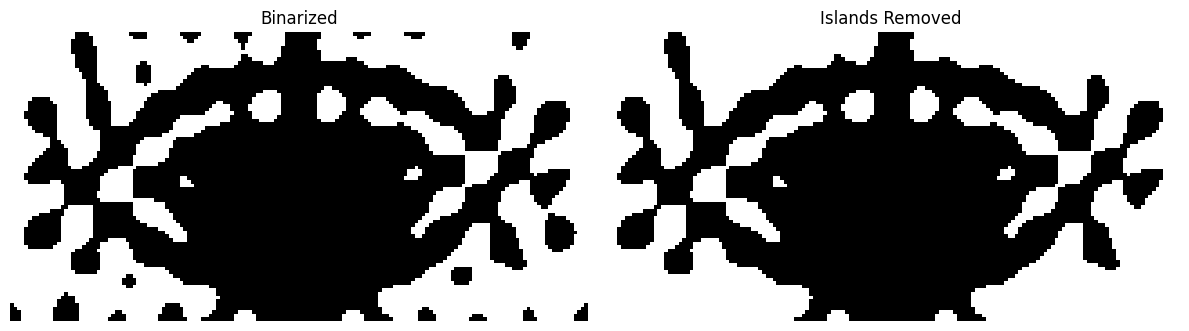

In [2]:
import numpy as np
from scipy.ndimage import label, binary_fill_holes

# ------------------------------------------------------------------ #
#  1. 二值化
# ------------------------------------------------------------------ #
threshold = 0.4
tt_bin = (tt >= threshold).astype(np.uint8)

# ------------------------------------------------------------------ #
#  2. 去除孤岛（保留最大连通域）
# ------------------------------------------------------------------ #
structure = np.ones((3, 3), dtype=int)          # 8-连通
labeled, num_features = label(tt_bin, structure=structure)

if num_features == 0:
    tt_clean = tt_bin.copy()
else:
    # 统计每个连通域的像素数，保留最大的
    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0                      # 背景不参与比较
    largest_label = component_sizes.argmax()
    tt_clean = (labeled == largest_label).astype(np.uint8)

print(f"二值化后体积分数   : {tt_bin.mean():.4f}")
print(f"去孤岛后体积分数   : {tt_clean.mean():.4f}")
print(f"连通域数量         : {num_features}")

# ------------------------------------------------------------------ #
#  3. 可视化对比
# ------------------------------------------------------------------ #
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(1 - tt_bin,  cmap='gray', vmin=0, vmax=1)
axes[0].set_title("Binarized")
axes[0].axis('off')

axes[1].imshow(1 - tt_clean, cmap='gray', vmin=0, vmax=1)
axes[1].set_title("Islands Removed")
axes[1].axis('off')

plt.tight_layout()
plt.savefig("tt_clean.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve


def calc_compliance_mbb(xPhys, penal=3):
    """
    计算 MBB 梁给定密度矩阵的 compliance。

    边界条件
    --------
    - 滚动支撑 (u_y = 0) : 底边左下角节点 (i=nely, j=0)
                           底边右下角节点 (i=nely, j=nelx)
    - 集中载荷 (F_y = -1): 底边中点节点   (i=nely, j=nelx//2)

    节点编号约定 (与 cantilever 版本一致，column-major / Fortran order)
    ---------------------------------------------------------------
    nodenrs[i, j] = j*(nely+1) + i + 1   (1-indexed)
    x-DOF = 2*(node-1),   y-DOF = 2*(node-1)+1

    Parameters
    ----------
    xPhys : np.ndarray, shape (nely, nelx)
        密度矩阵，值域 [0, 1]。
    penal : float
        惩罚指数，默认 3。

    Returns
    -------
    c : float
        结构柔度（compliance）。
    """
    nely, nelx = xPhys.shape

    # ------------------------------------------------------------------ #
    #  MATERIAL PROPERTIES
    # ------------------------------------------------------------------ #
    E0   = 1.0
    Emin = 1e-9
    nu   = 0.3

    # ------------------------------------------------------------------ #
    #  ELEMENT STIFFNESS MATRIX  (与 cantilever 版本完全相同)
    # ------------------------------------------------------------------ #
    A11 = np.array([[ 12,  3, -6, -3],
                    [  3, 12,  3,  0],
                    [ -6,  3, 12, -3],
                    [ -3,  0, -3, 12]])
    A12 = np.array([[ -6, -3,  0,  3],
                    [ -3, -6, -3, -6],
                    [  0, -3, -6,  3],
                    [  3, -6,  3, -6]])
    B11 = np.array([[ -4,  3, -2,  9],
                    [  3, -4, -9,  4],
                    [ -2, -9, -4, -3],
                    [  9,  4, -3, -4]])
    B12 = np.array([[  2, -3,  4, -9],
                    [ -3,  2,  9, -2],
                    [  4,  9,  2,  3],
                    [ -9, -2,  3,  2]])
    KE = (1 / (1 - nu**2) / 24) * (
        np.block([[A11, A12], [A12.T, A11]])
        + nu * np.block([[B11, B12], [B12.T, B11]])
    )

    # ------------------------------------------------------------------ #
    #  DOF MAP  (与 cantilever 版本完全相同)
    # ------------------------------------------------------------------ #
    ndof    = 2 * (nelx + 1) * (nely + 1)
    nodenrs = np.arange(1, (1+nelx)*(1+nely)+1).reshape(1+nely, 1+nelx, order='F')
    edofVec = (2 * nodenrs[:nely, :nelx] + 1).reshape(nelx*nely, 1, order='F')
    offsets = np.array([0, 1, 2*nely+2, 2*nely+3, 2*nely, 2*nely+1, -2, -1])
    edofMat = (np.tile(edofVec, (1, 8)) + np.tile(offsets, (nelx*nely, 1)) - 1).astype(int)

    iK = np.tile(edofMat, 8).flatten().astype(int)
    jK = np.repeat(edofMat, 8, axis=1).flatten().astype(int)

    # ------------------------------------------------------------------ #
    #  LOADS AND SUPPORTS  ← MBB 专用
    #
    #  节点 (i, j):  i = 行索引 0..nely（底边 = i=nely）
    #                j = 列索引 0..nelx（左=0, 右=nelx, 中=nelx//2）
    #  node (1-indexed) = j*(nely+1) + i + 1
    #  y-DOF = 2*(node-1) + 1
    # ------------------------------------------------------------------ #
    F = np.zeros(ndof)

    # 底边中点集中载荷  F_y = -1
    node_force = (nelx // 2) * (nely + 1) + nely        # 0-indexed node
    F[2 * node_force + 1] = -1.0

    # 滚动支撑：只约束 y 方向自由度 (u_y = 0)
    node_bl = 0 * (nely + 1) + nely                     # 底边左下角 (j=0,    i=nely)
    node_br = nelx * (nely + 1) + nely                  # 底边右下角 (j=nelx, i=nely)
    fixeddofs = np.array([2 * node_bl + 1,
                          2 * node_br + 1], dtype=int)

    freedofs = np.setdiff1d(np.arange(ndof), fixeddofs)

    # ------------------------------------------------------------------ #
    #  ASSEMBLE & SOLVE
    # ------------------------------------------------------------------ #
    elem_mods = Emin + xPhys.flatten(order='F')**penal * (E0 - Emin)
    sK = (KE.flatten(order='F')[:, None] * elem_mods[None, :]).flatten(order='F')
    K  = sp.csr_matrix((sK, (iK, jK)), shape=(ndof, ndof))
    K  = (K + K.T) / 2

    U = np.zeros(ndof)
    U[freedofs] = spsolve(K[freedofs, :][:, freedofs], F[freedofs])

    # ------------------------------------------------------------------ #
    #  COMPLIANCE
    # ------------------------------------------------------------------ #
    Ue = U[edofMat]
    ce = (Ue @ KE * Ue).sum(axis=1).reshape(nely, nelx, order='F')
    c  = np.sum((Emin + xPhys**penal * (E0 - Emin)) * ce)

    return c

In [4]:
calc_compliance_mbb(tt)

150088.81117402084

In [5]:
calc_compliance_mbb(tt_clean)

4582556307.04536

(-0.5, 159.5, 79.5, -0.5)

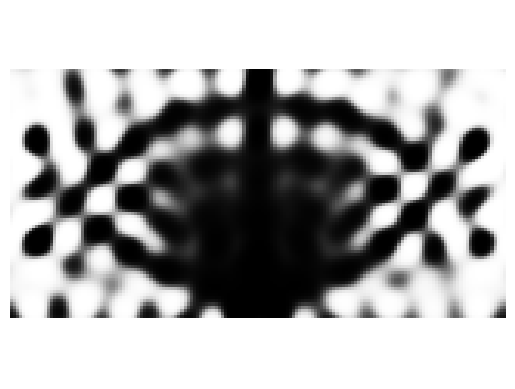

In [6]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.imshow(-tt, cmap='gray')
plt.axis('equal')
plt.axis('off')
#plt.savefig("./mbb44.pdf",dpi=300)

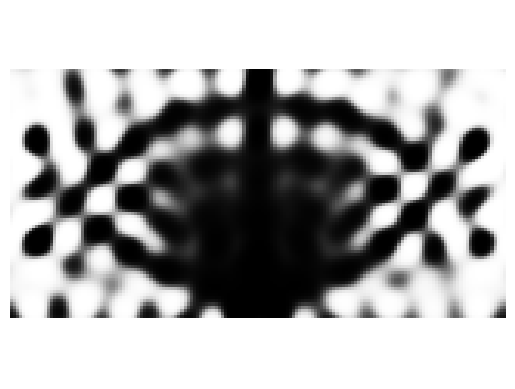

In [7]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.imshow(-tt, cmap='gray')
plt.axis('equal')
plt.axis('off')
plt.savefig("./DMFmbb.pdf",dpi=300)

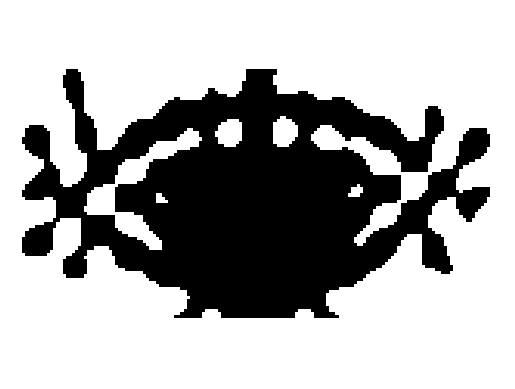

In [9]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.imshow(1-tt_clean, cmap='gray')
plt.axis('equal')
plt.axis('off')
plt.savefig("./DMFmbb_clean.pdf",dpi=300)